# Create globe maps with a nice background

In [1]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from matplotlib.ticker import MultipleLocator

def plot_global_map_on_globe(
    image_path:str = None,
    central_longitude=0,
    central_latitude=0,
    show_coastlines=True,
    show_borders=True,
    show_land=True,
    show_ocean=True,
    show_gridlines=True,
    gridline_interval=(30, 30),  # Interval for longitude and latitude grid lines
    extent=[-180, 180, -90, 90],  # or [0, 360, -90, 90]
    figsize=(5, 5),
    show_plot=True,
    title=None,
):
    # Load image
    if image_path:
        img = mpimg.imread(image_path)

    # Projection
    globe_proj = ccrs.Orthographic(central_longitude=central_longitude,
                                   central_latitude=central_latitude)
    image_proj = ccrs.PlateCarree()

    # Plot
    fig = plt.figure(figsize=figsize)
    ax = plt.axes(projection=globe_proj)
    ax.set_global()
    
    # Show image across globe
    if image_path:
        ax.imshow(
            img,
            origin='upper',
            transform=image_proj,
            extent=extent,
            interpolation='bilinear'
        )

    # Optional map features
    if show_coastlines:
        ax.coastlines()
    if show_borders:
        ax.add_feature(cfeature.BORDERS, linestyle=':')
    if show_land:
        ax.add_feature(cfeature.LAND, edgecolor='black', facecolor=cfeature.COLORS['land'])
    if show_ocean:
        ax.add_feature(cfeature.OCEAN, facecolor=cfeature.COLORS['water'])
    if show_gridlines:
        gl = ax.gridlines(draw_labels=False, color='gray', linestyle='--', linewidth=0.5)
        gl.xlines = True
        gl.ylines = True
        # Set grid line intervals
        gl.xlocator = MultipleLocator(gridline_interval[0])  # Longitude interval
        gl.ylocator = MultipleLocator(gridline_interval[1])  # Latitude interval

    if title is None:
        title = f"Orthographic Projection ({central_longitude}, {central_latitude})"
        
    plt.title(title)
    
    if show_plot:
        plt.show()
    
    return fig, ax

In [2]:
import requests

def download_image(url, save_path):
    """
    Downloads an image from the given URL and saves it to the specified path.

    Parameters:
        url (str): The URL of the image to download.
        save_path (str): The local file path where the image will be saved.
    """
    try:
        # Send a GET request to the URL
        response = requests.get(url, stream=True)
        
        # Check if the request was successful
        if response.status_code == 200:
            # Open the file in binary write mode and save the image
            with open(save_path, 'wb') as file:
                for chunk in response.iter_content(1024):  # Download in chunks
                    file.write(chunk)
            print(f"Image successfully downloaded and saved to {save_path}")
        else:
            print(f"Failed to download image. HTTP Status Code: {response.status_code}")
    except Exception as e:
        print(f"An error occurred: {e}")


Mars image downloaded from https://gis.stackexchange.com/questions/424598/convert-mars-tiff-file-on-simple-cyllindrical-projection-to-a-geotiff

In [3]:
mars_img = "https://i.sstatic.net/nQZqG.jpg"
download_image(mars_img, "mars_img.jpg")

An error occurred: HTTPSConnectionPool(host='i.sstatic.net', port=443): Max retries exceeded with url: /nQZqG.jpg (Caused by SSLError(SSLCertVerificationError(1, '[SSL: CERTIFICATE_VERIFY_FAILED] certificate verify failed: self-signed certificate in certificate chain (_ssl.c:997)')))


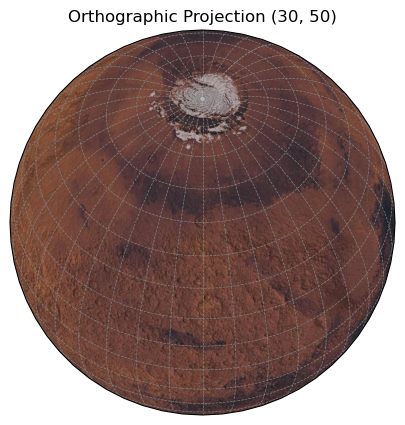

(<Figure size 500x500 with 1 Axes>,
 <GeoAxes: title={'center': 'Orthographic Projection (30, 50)'}>)

In [4]:
plot_global_map_on_globe(
    image_path="mars_img.jpg",
    central_longitude=30,
    central_latitude=50,
    show_coastlines=False,
    show_borders=False,
    show_land=False,
    show_ocean=False,
    show_gridlines=True,
    gridline_interval=(10,10)
)

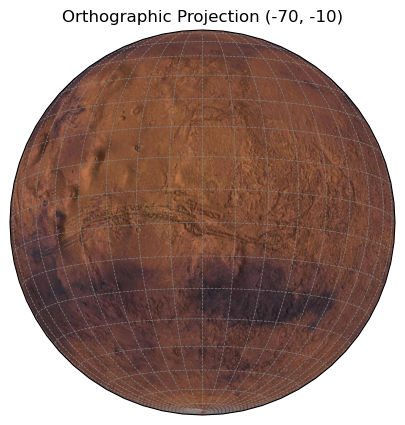

(<Figure size 500x500 with 1 Axes>,
 <GeoAxes: title={'center': 'Orthographic Projection (-70, -10)'}>)

In [5]:
plot_global_map_on_globe(
    image_path="mars_img.jpg",
    central_longitude=-70,
    central_latitude=-10,
    show_coastlines=False,
    show_borders=False,
    show_land=False,
    show_ocean=False,
    show_gridlines=True,
    gridline_interval=(10, 10)
)

NASA's collection of Blue Marble images: https://visibleearth.nasa.gov/collection/1484/blue-marble

One used in this notebook: https://visibleearth.nasa.gov/images/73909/december-blue-marble-next-generation-w-topography-and-bathymetry

In [6]:
blue_marble_img = "https://eoimages.gsfc.nasa.gov/images/imagerecords/73000/73909/world.topo.bathy.200412.3x5400x2700.jpg"
blue_marble_img_downloaded = blue_marble_img.split("/")[-1]

download_image(blue_marble_img, blue_marble_img_downloaded)

Image successfully downloaded and saved to world.topo.bathy.200412.3x5400x2700.jpg


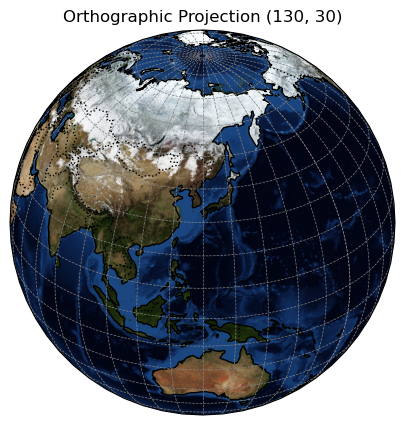

In [7]:
# Download blue marble image
fig, ax = plot_global_map_on_globe(
    image_path=blue_marble_img_downloaded,
    central_longitude=130,
    central_latitude=30,
    show_coastlines=True,
    show_borders=True,
    show_land=True,
    show_ocean=True,
    show_gridlines=True,
    gridline_interval=(10, 10)
)

Sample data to superimpose on the map: https://scitools.org.uk/cartopy/docs/v0.14/examples/waves.html

In [8]:
import numpy as np

def sample_data(shape=(73, 145)):
    """Returns ``lons``, ``lats`` and ``data`` of some fake data."""
    nlats, nlons = shape
    lats = np.linspace(-np.pi / 2, np.pi / 2, nlats)
    lons = np.linspace(0, 2 * np.pi, nlons)
    lons, lats = np.meshgrid(lons, lats)
    wave = 0.75 * (np.sin(2 * lats) ** 8) * np.cos(4 * lons)
    mean = 0.5 * np.cos(2 * lats) * ((np.sin(2 * lats)) ** 2 + 2)

    lats = np.rad2deg(lats)
    lons = np.rad2deg(lons)
    data = wave + mean

    return lons, lats, data

lons, lats, data = sample_data()

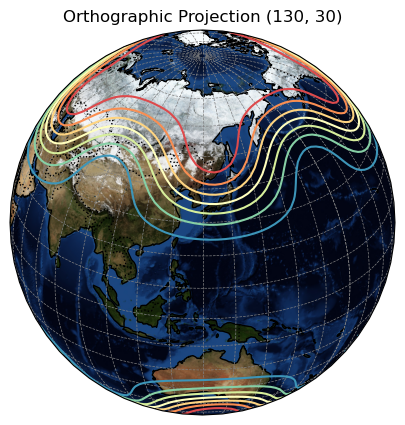

In [9]:
fig, ax = plot_global_map_on_globe(
    image_path=blue_marble_img_downloaded,
    central_longitude=130,
    central_latitude=30,
    show_coastlines=True,
    show_borders=True,
    show_land=True,
    show_ocean=True,
    show_gridlines=True,
    gridline_interval=(10, 10),
    show_plot=False,
)

ax.contour(lons, lats, data,
            transform=ccrs.PlateCarree(),
            cmap='Spectral')

plt.show()

fig.savefig('test_contour.png')

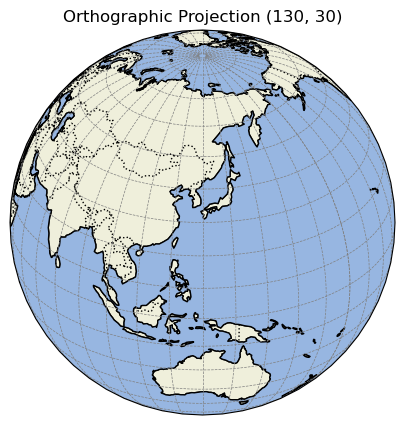

(<Figure size 500x500 with 1 Axes>,
 <GeoAxes: title={'center': 'Orthographic Projection (130, 30)'}>)

In [10]:
# Download blue marble image
plot_global_map_on_globe(
    image_path=None,
    central_longitude=130,
    central_latitude=30,
    show_coastlines=True,
    show_borders=True,
    show_land=True,
    show_ocean=True,
    show_gridlines=True,
    gridline_interval=(10, 10)
)

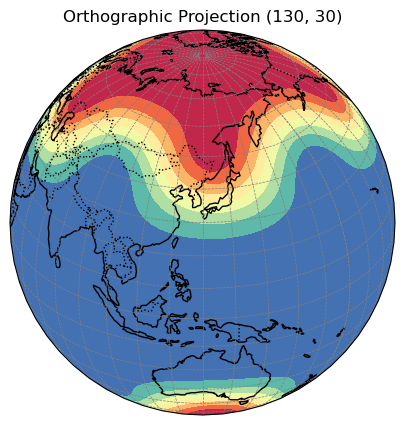

In [11]:
fig, ax = plot_global_map_on_globe(
    image_path=None,
    central_longitude=130,
    central_latitude=30,
    show_coastlines=True,
    show_borders=True,
    show_land=True,
    show_ocean=True,
    show_gridlines=True,
    gridline_interval=(10, 10),
    show_plot=False,
)

ax.contourf(lons, lats, data,
            transform=ccrs.PlateCarree(),
            cmap='Spectral')

plt.show()

fig.savefig('test_contourf.png')